[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AstroAI-CfA/tutorial-lsdb/blob/main/tutorials/Notebook_1_Solution.ipynb)

Author: Konstantin Malanchev and the LINCC Frameworks team

Last updated: June 2026

# Problem 1: Color-Magnitude Diagram of the h and χ Persei Double Cluster

The h and χ Persei double cluster (NGC 869 and NGC 884) is a pair of young open clusters at ~2.3 kpc, both visible to the naked eye in Perseus. Because the member stars are all at roughly the same distance and share a common proper motion, they stand out clearly as overdensities in proper-motion and parallax space.

**Task:** isolate the cluster members from the Milky Way field and plot their color-magnitude diagram.

**Steps:**
1. Load Gaia DR3 in a 1-degree cone around RA = 34.9 deg, Dec = +57.1 deg. Include `phot_g_mean_mag`, `bp_rp`, `parallax`, `pmra`, and `pmdec`. Compute the result.
2. Plot histograms of `pmra`, `pmdec`, and `parallax`. You should see a clear overdensity from the cluster on top of the smooth Milky Way background.
3. Select cluster members by cutting on those three quantities around the overdensity peaks.
4. Plot apparent G magnitude (y-axis, inverted) vs BP-RP color (x-axis).

**Advanced:** instead of computing first and histogramming the pandas dataframe, try to compute the histograms lazily directly on the LSDB catalog. See the [LSDB plotting tutorial](https://docs.lsdb.io/en/latest/tutorials/pre_executed/plotting.html#7.2-Across-the-Sky) for an example.

## Solution

In [1]:
# do you need to install the package?
# if yes, uncomment the line below and restart the kernel
# %pip install -U lsdb s3fs

In [2]:
import logging
import warnings

import astropy.units as u
import lsdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from dask.distributed import Client
from lsdb import ConeSearch
from matplotlib import rcParams

%matplotlib inline

warnings.simplefilter("ignore")
logging.getLogger("distributed").setLevel(logging.WARNING)
rcParams["savefig.dpi"] = 150
rcParams["font.size"] = 14
mpl.rcParams["axes.linewidth"] = 1.5

In [3]:
client = Client(n_workers=2, memory_limit="4GiB", threads_per_worker=1)
print(f"Dask dashboard: {client.dashboard_link}")

Dask dashboard: http://127.0.0.1:8787/status


## Step 1: Load Gaia DR3 in a cone around h and χ Persei

In [4]:
gaia_path = "s3://stpubdata/gaia/gaia_dr3/public/hats"

# h Per (NGC 869) is at RA~34.75, Dec~+57.13
# χ Per (NGC 884) is at RA~35.08, Dec~+57.15
# A 1-degree cone centered between them captures both clusters
cone = ConeSearch(ra=34.9, dec=57.1, radius_arcsec=1.0 * 3600)

gaia_hchi = lsdb.open_catalog(
    gaia_path,
    columns=["source_id", "ra", "dec", "phot_g_mean_mag", "bp_rp", "parallax", "pmra", "pmdec"],
    search_filter=cone,
)

In [5]:
%%time
df = gaia_hchi.compute()
print(f"Stars in cone: {len(df):,}")

Stars in cone: 203,132
CPU times: user 460 ms, sys: 189 ms, total: 649 ms
Wall time: 17.2 s


## Step 2: Explore distributions with histograms

Plot histograms of `pmra`, `pmdec`, and `parallax`. The cluster members show up as a sharp peak on top of the smooth Milky Way background.

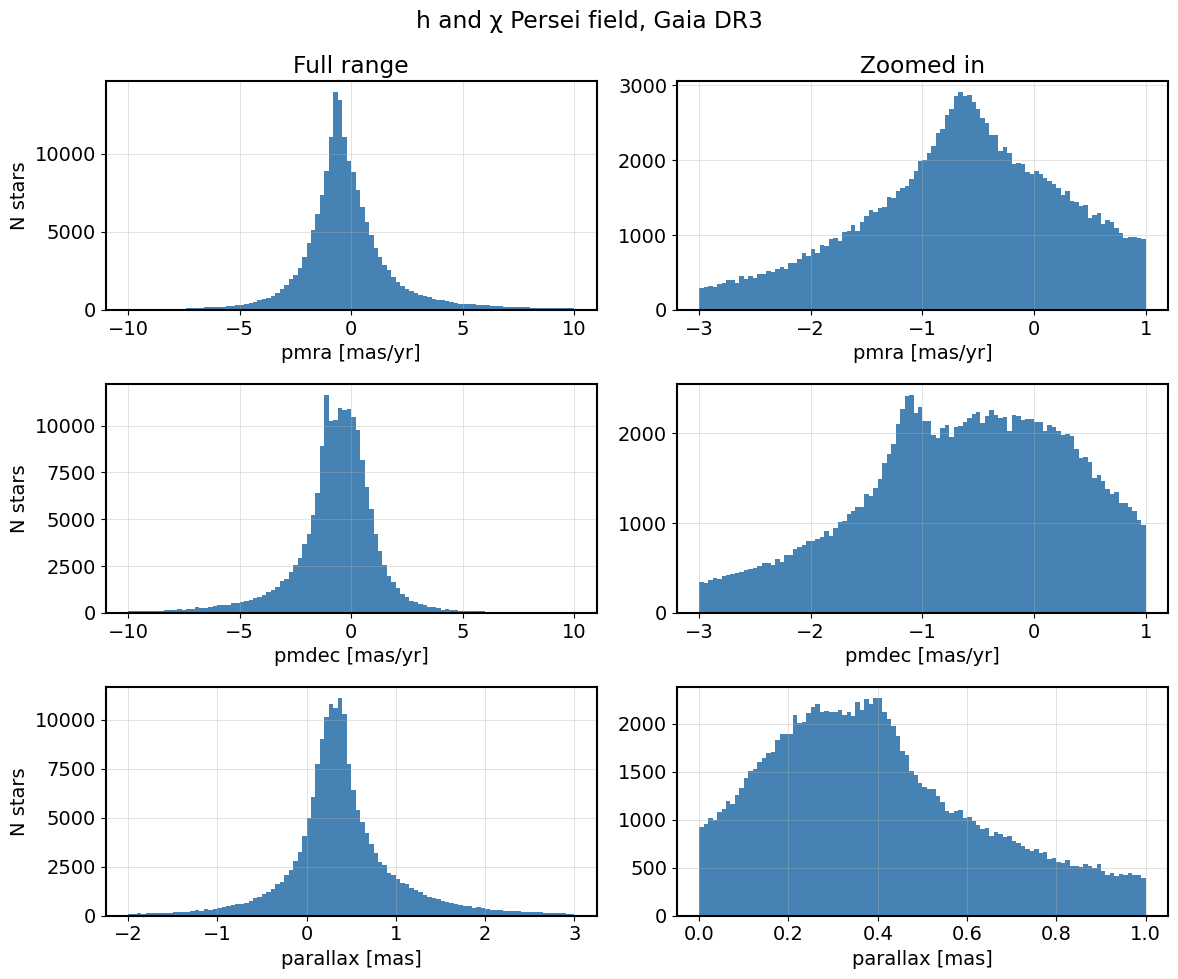

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

cols = ["pmra", "pmdec", "parallax"]
labels = ["pmra [mas/yr]", "pmdec [mas/yr]", "parallax [mas]"]
wide_ranges = [(-10, 10), (-10, 10), (-2, 3)]
zoom_ranges = [(-3, 1), (-3, 1), (0, 1)]

for i, (col, label, wide, zoom) in enumerate(zip(cols, labels, wide_ranges, zoom_ranges)):
    data = df[col].dropna()
    axes[i, 0].hist(data, bins=100, range=wide, color="steelblue", edgecolor="none")
    axes[i, 0].set_xlabel(label)
    axes[i, 0].set_ylabel("N stars")
    axes[i, 0].grid()

    axes[i, 1].hist(data, bins=100, range=zoom, color="steelblue", edgecolor="none")
    axes[i, 1].set_xlabel(label)
    axes[i, 1].grid()

axes[0, 0].set_title("Full range")
axes[0, 1].set_title("Zoomed in")

plt.suptitle("h and χ Persei field, Gaia DR3")
plt.tight_layout()
plt.show()

## Step 3: Select cluster members

We apply the cuts as a `.query()` on the lazy LSDB catalog, not on the computed dataframe. The filter runs partition-by-partition in parallel when `.compute()` is called.

Set the boundaries based on the histogram peaks above, then rerun.

In [7]:
# Adjust these values after inspecting the histograms
PMRA_MIN, PMRA_MAX = -1.0, 0.0
PMDEC_MIN, PMDEC_MAX = -1.3, -1.0
PARALLAX_MIN, PARALLAX_MAX = 0.3, 0.5

# Query on the lazy LSDB catalog object; filtering happens per-partition in parallel.
# Use f-string interpolation to embed the values; Dask does not support the @variable syntax.
members_catalog = gaia_hchi.query(
    f"{PMRA_MIN} < pmra < {PMRA_MAX} and "
    f"{PMDEC_MIN} < pmdec < {PMDEC_MAX} and "
    f"{PARALLAX_MIN} < parallax < {PARALLAX_MAX}"
)

In [8]:
# An alternative is to pass filters= directly to open_catalog.
# This enables parquet predicate pushdown: the parquet reader skips entire row
# groups that cannot satisfy the filter before loading them into memory,
# which can be significantly faster when the cuts are tight.
#
# members_catalog = lsdb.open_catalog(
#     gaia_path,
#     columns=["source_id", "ra", "dec", "phot_g_mean_mag", "bp_rp", "parallax", "pmra", "pmdec"],
#     search_filter=cone,
#     filters=[
#         ("pmra", ">", PMRA_MIN), ("pmra", "<", PMRA_MAX),
#         ("pmdec", ">", PMDEC_MIN), ("pmdec", "<", PMDEC_MAX),
#         ("parallax", ">", PARALLAX_MIN), ("parallax", "<", PARALLAX_MAX),
#     ],
# )

In [9]:
members = members_catalog.compute()
print(f"Candidate cluster members: {len(members):,}")

Candidate cluster members: 4,852


## Step 4: Color-magnitude diagram

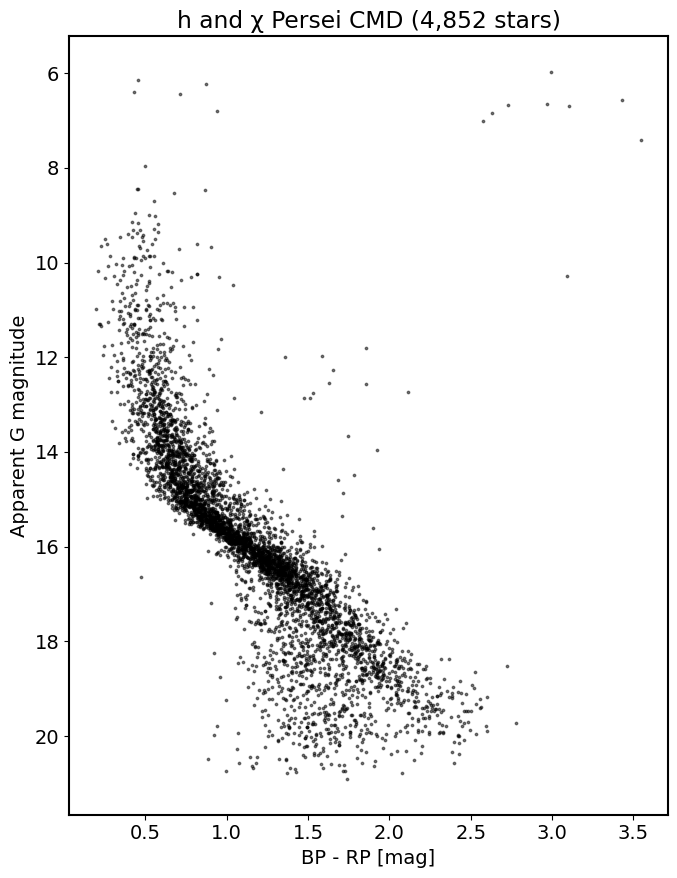

In [10]:
fig, ax = plt.subplots(figsize=(7, 9))
ax.scatter(members["bp_rp"], members["phot_g_mean_mag"], s=3, alpha=0.5, color="black", rasterized=True)
ax.set_xlabel("BP - RP [mag]")
ax.set_ylabel("Apparent G magnitude")
ax.set_title(f"h and χ Persei CMD ({len(members):,} stars)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Sky map: before and after filtering

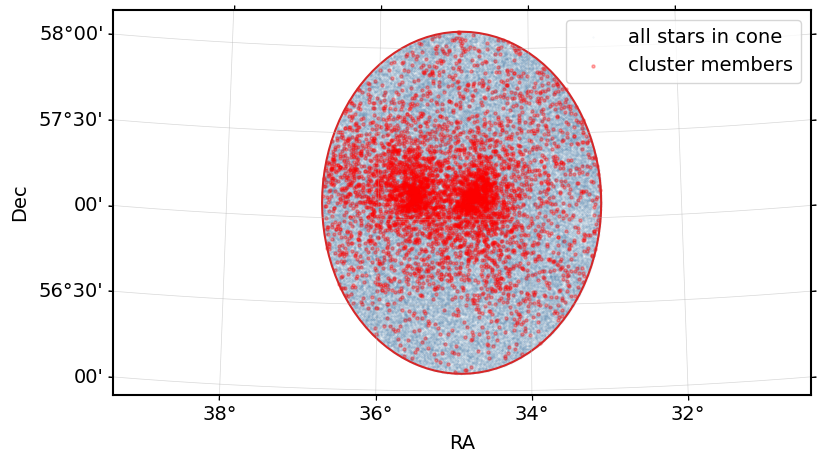

In [11]:
center = SkyCoord(ra=cone.ra * u.deg, dec=cone.dec * u.deg)
fov = 2.5 * cone.radius_arcsec * u.arcsec

# First call creates the WCSAxes; subsequent calls reuse it automatically
gaia_hchi.plot_points(title="Sky map", center=center, fov=fov, s=0.1, alpha=0.1, c="steelblue", label="all stars in cone")
members_catalog.plot_points(s=5, alpha=0.3, c="red", label="cluster members")
cone.plot(facecolor="none", edgecolor="orange", linewidth=1.5)
plt.legend()
plt.show()

## Bonus: Lazy histograms with `map_partitions`

The approach above calls `.compute()` on the full cone first, loading all ~200k rows into memory before histogramming. For large catalogs you can instead compute the histogram lazily: `map_partitions` applies a function to each partition independently, returning a small summary dataframe (bin index + count). Summing those after `.compute()` gives the same result but only ever holds a few partitions in memory at a time.

See the [LSDB plotting tutorial](https://docs.lsdb.io/en/latest/tutorials/pre_executed/plotting.html#7.2-Across-the-Sky) for more examples of lazy aggregations.

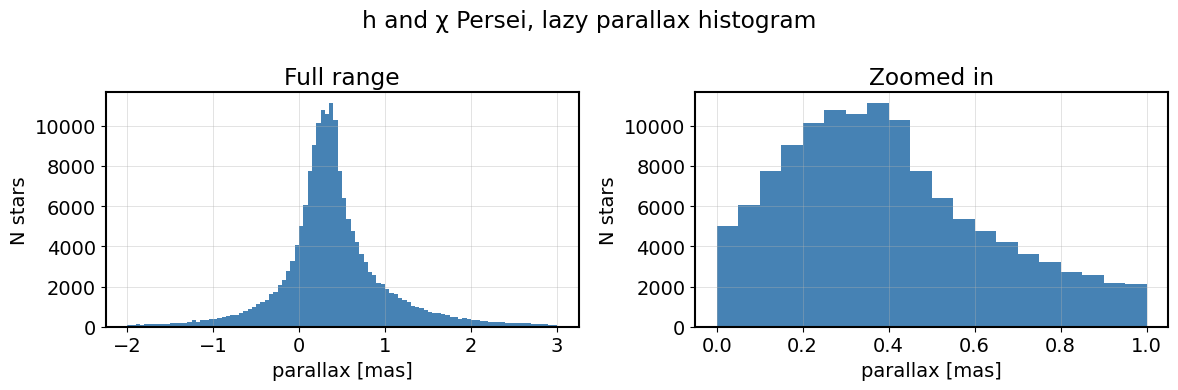

In [12]:
edges = np.linspace(-2, 3, 101)
bin_indices = np.arange(len(edges) - 1)

def partition_hist(df):
    counts, _ = np.histogram(df["parallax"].dropna(), bins=edges)
    return pd.DataFrame({"bin": bin_indices, "count": counts})

partial_hists = gaia_hchi.map_partitions(
    partition_hist,
    meta=pd.DataFrame({"bin": pd.Series(dtype=int), "count": pd.Series(dtype=int)}),
)
counts = partial_hists.compute().groupby("bin")["count"].sum().values
bin_centers = (edges[:-1] + edges[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (lo, hi) in zip(axes, [(-2, 3), (0, 1)]):
    mask = (bin_centers >= lo) & (bin_centers <= hi)
    ax.bar(bin_centers[mask], counts[mask], width=np.diff(edges)[mask], align="center", color="steelblue")
    ax.set_xlabel("parallax [mas]")
    ax.set_ylabel("N stars")
    ax.grid()
axes[0].set_title("Full range")
axes[1].set_title("Zoomed in")
plt.suptitle("h and χ Persei, lazy parallax histogram")
plt.tight_layout()
plt.show()

In [13]:
client.close()